In [32]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

In [33]:
base_url = "https://www.globalfirepower.com/countries-listing.php"

other_sources = {
    "https://www.globalfirepower.com/total-population-by-country.php": "total_population",
    "https://www.globalfirepower.com/available-military-manpower.php": "total_military_manpower",
    "https://www.globalfirepower.com/manpower-fit-for-military-service.php": "fit_for_service",
    "https://www.globalfirepower.com/manpower-reaching-military-age-annually.php": "population_reaching_military_age_annually",
    "https://www.globalfirepower.com/active-military-manpower.php": "active_personnel",
    "https://www.globalfirepower.com/active-reserve-military-manpower.php": "reserve_personnel",
    "https://www.globalfirepower.com/manpower-paramilitary.php": "paramilitary",
    "https://www.globalfirepower.com/aircraft-total.php": "total_military_aircraft",
    "https://www.globalfirepower.com/aircraft-total-fighters.php": "fighter_aircraft",
    "https://www.globalfirepower.com/aircraft-total-attack-types.php": "attack_aircraft",
    "https://www.globalfirepower.com/aircraft-total-transports.php": "transport_aircraft",
    "https://www.globalfirepower.com/aircraft-total-trainers.php": "trainer_aircraft",
    "https://www.globalfirepower.com/aircraft-total-special-mission.php": "special_mission_aircraft",
    "https://www.globalfirepower.com/aircraft-total-tanker-fleet.php": "tanker_aircraft",
    "https://www.globalfirepower.com/aircraft-helicopters-total.php": "total_military_helicopters",
    "https://www.globalfirepower.com/aircraft-helicopters-attack.php": "attack_helicopters",
    "https://www.globalfirepower.com/armor-tanks-total.php": "tanks",
    "https://www.globalfirepower.com/armor-apc-total.php": "armored_fighting_vehicles",
    "https://www.globalfirepower.com/armor-self-propelled-guns-total.php": "self_propelled_artillery",
    "https://www.globalfirepower.com/armor-towed-artillery-total.php": "towed_artillery",
    "https://www.globalfirepower.com/armor-mlrs-total.php": "rocket_projectors",
    "https://www.globalfirepower.com/navy-ships.php": "total_naval_fleet",
    "https://www.globalfirepower.com/navy-force-by-tonnage.php": "total_naval_fleet_tonnage_mt",
    "https://www.globalfirepower.com/navy-aircraft-carriers.php": "aircraft_carriers",
    "https://www.globalfirepower.com/navy-helo-carriers.php": "helicopter_carriers",
    "https://www.globalfirepower.com/navy-submarines.php": "submarines",
    "https://www.globalfirepower.com/navy-destroyers.php": "destroyers",
    "https://www.globalfirepower.com/navy-frigates.php": "frigates",
    "https://www.globalfirepower.com/navy-corvettes.php": "corvettes",
    "https://www.globalfirepower.com/navy-patrol-coastal-craft.php": "coastal_patrol_craft",
    "https://www.globalfirepower.com/navy-mine-warfare-craft.php": "mine_warfare_craft",
    "https://www.globalfirepower.com/defense-spending-budget.php": "defense_budget_usd",
    "https://www.globalfirepower.com/external-debt-by-country.php": "external_debt_usd",
    "https://www.globalfirepower.com/purchasing-power-parity.php": "purchasing_power_parity_usd",
    "https://www.globalfirepower.com/reserves-of-foreign-exchange-and-gold.php": "foreign_exchange_and_gold_reserves_usd",
    "https://www.globalfirepower.com/major-serviceable-airports-by-country.php": "total_serviceable_airports",
    "https://www.globalfirepower.com/labor-force-by-country.php": "labour_force",
    "https://www.globalfirepower.com/major-ports-and-terminals.php": "major_ports_and_terminals",
    "https://www.globalfirepower.com/merchant-marine-strength-by-country.php": "total_merchant_marine_fleet",
    "https://www.globalfirepower.com/railway-coverage.php": "railway_coverage_km",
    "https://www.globalfirepower.com/roadway-coverage.php": "roadway_coverage_km",
    "https://www.globalfirepower.com/oil-production-by-country.php": "oil_production_bbl",
    "https://www.globalfirepower.com/oil-consumption-by-country.php": "oil_consumption_bbl",
    "https://www.globalfirepower.com/proven-oil-reserves-by-country.php": "proven_oil_reserves_bbl",
    "https://www.globalfirepower.com/natural-gas-production-by-country.php": "natural_gas_production_cum",
    "https://www.globalfirepower.com/natural-gas-consumption-by-country.php": "natural_gas_consumption_cum",
    "https://www.globalfirepower.com/proven-natural-gas-reserves-by-country.php": "proven_natural_gas_reserves_cum",
    "https://www.globalfirepower.com/coal-production-by-country.php": "coal_production_cum",
    "https://www.globalfirepower.com/coal-consumption-by-country.php": "coal_consumption_mt",
    "https://www.globalfirepower.com/proven-coal-reserves-by-country.php": "proven_coal_reserves_cum",
    "https://www.globalfirepower.com/square-land-area.php": "total_land_area_sq_km",
    "https://www.globalfirepower.com/coastline-coverage.php": "coastline_coverage_km",
    "https://www.globalfirepower.com/border-coverage.php": "border_coverage_km",
    "https://www.globalfirepower.com/waterway-coverage.php": "waterway_coverage_km"
}

In [34]:
def scrape_global_firepower_data():
    response = requests.get(base_url, timeout=30)
    soup = BeautifulSoup(response.text, "lxml")

    containers = soup.find_all(
        "div", class_="picTrans recordsetContainer boxShadow zoom"
    )

    print("Base containers found:", len(containers))

    ranks = []
    countries = []

    for item in containers:
        rank = item.find("span", class_="textWhite textLarge textBold")
        country = item.find("span", class_="textWhite textLarge textShadow")

        if rank and country:
            ranks.append(rank.text.strip())
            countries.append(country.text.strip())

    df_main = pd.DataFrame({
        "rank": ranks,
        "country": countries
    })

    for url, col_name in other_sources.items():
        r = requests.get(url, timeout=30)
        s = BeautifulSoup(r.text, "lxml")

        containers = s.find_all(
            "div", class_="picTrans recordsetContainer boxShadow zoom"
        )

        temp_countries = []
        values = []

        for item in containers:
            c = item.find("span", class_="textWhite textLarge textShadow")
            v = item.find_all("span", class_="textWhite textLarge")[-1]

            if c and v:
                temp_countries.append(c.text.strip())
                values.append(
                    re.sub(r"[^\d.]", "", v.text)
                )

        df_temp = pd.DataFrame({
            "country": temp_countries,
            col_name: values
        })

        df_main = df_main.merge(df_temp, on="country", how="left")

    return df_main

In [35]:
df = scrape_global_firepower_data()

Base containers found: 145


In [36]:
df.head(10)

,rank,country,total_population,total_military_manpower,fit_for_service,population_reaching_military_age_annually,active_personnel,reserve_personnel,paramilitary,total_military_aircraft,...,natural_gas_production_cum,natural_gas_consumption_cum,proven_natural_gas_reserves_cum,coal_production_cum,coal_consumption_mt,proven_coal_reserves_cum,total_land_area_sq_km,coastline_coverage_km,border_coverage_km,waterway_coverage_km
0,1,United States,341963408,150463900,124816644,4445524,1328000,799500,0,13043,...,1029000000000.,914301000000.,13402000000000.,548849000.,476044000,248941000000.,9833517,19924,12002,41009
1,2,Russia,140820810,69002197,46189226,1267387,1320000,2000000,250000,4292,...,617830000000.,472239000000.,47805000000000.,508190000.,310958000,162166000000.,17098242,37653,22407,102000
2,3,China,1415043270,764123366,626864169,19810606,2035000,510000,625000,3309,...,225341000000.,366160000000.,6654000000000.,4827000000.,5313000000,143197000000.,9596960,14500,22457,27700
3,4,India,1409128296,662290299,522786598,23955181,1455550,1155000,2527000,2229,...,33170000000.,58867000000.,1381000000000.,985671000.,1200000000,111052000000.,3287263,7000,13888,14500
4,5,South Korea,52081799,26040900,21353538,416654,600000,3100000,120000,1592,...,55127000.,59480000000.,7079000000.,15595000.,136413000,326000000.,99720,2413,237,1600
5,6,United Kingdom,68459055,31491165,25192932,753050,184860,924000,0,631,...,37758000000.,70141000000.,180661000000.,1891000.,8568000,26000000.,243610,12429,443,3200
6,7,France,68374591,30084820,23794358,752121,200000,26000,150000,976,...,20132000.,37001000000.,7787000000.,2419000.,12985000,160000000.,643801,4853,4072,8501
7,8,Japan,123201945,52976836,42874277,1108818,247150,56000,25000,1443,...,2220000000.,92843000000.,20898000000.,29141000.,216332000,350000000.,377915,29751,0,1770
8,9,Turkiye,84119531,42985080,36087279,1430032,355200,378700,150000,1083,...,379701000.,2887000000.,3794000000.,88746000.,123976000,11525000000.,783562,7200,2816,1200
9,10,Italy,60964931,27434219,22191235,548684,165500,18500,105000,729,...,3117000000.,68735000000.,45750000000.,1618000.,13127000,609999000.,301340,7600,1836,2400


In [37]:
df.to_csv("military_raw.csv", index=False)
print("Raw CSV saved")

Raw CSV saved


In [38]:
df = pd.read_csv("military_raw.csv")
df.head()

,rank,country,total_population,total_military_manpower,fit_for_service,population_reaching_military_age_annually,active_personnel,reserve_personnel,paramilitary,total_military_aircraft,...,natural_gas_production_cum,natural_gas_consumption_cum,proven_natural_gas_reserves_cum,coal_production_cum,coal_consumption_mt,proven_coal_reserves_cum,total_land_area_sq_km,coastline_coverage_km,border_coverage_km,waterway_coverage_km
0,1,United States,341963408,150463900,124816644,4445524,1328000,799500,0,13043,...,1.029000e+12,9.143010e+11,1.340200e+13,5.488490e+08,476044000,2.489410e+11,9833517,19924,12002,41009
1,2,Russia,140820810,69002197,46189226,1267387,1320000,2000000,250000,4292,...,6.178300e+11,4.722390e+11,4.780500e+13,5.081900e+08,310958000,1.621660e+11,17098242,37653,22407,102000
2,3,China,1415043270,764123366,626864169,19810606,2035000,510000,625000,3309,...,2.253410e+11,3.661600e+11,6.654000e+12,4.827000e+09,5313000000,1.431970e+11,9596960,14500,22457,27700
3,4,India,1409128296,662290299,522786598,23955181,1455550,1155000,2527000,2229,...,3.317000e+10,5.886700e+10,1.381000e+12,9.856710e+08,1200000000,1.110520e+11,3287263,7000,13888,14500
4,5,South Korea,52081799,26040900,21353538,416654,600000,3100000,120000,1592,...,5.512700e+07,5.948000e+10,7.079000e+09,1.559500e+07,136413000,3.260000e+08,99720,2413,237,1600


In [39]:
df.replace("", pd.NA, inplace=True)
df.isna().sum()

,0
rank,0
country,0
total_population,0
total_military_manpower,0
fit_for_service,0
population_reaching_military_age_annually,0
active_personnel,0
reserve_personnel,0
paramilitary,0
total_military_aircraft,0


In [40]:
df.replace("", pd.NA, inplace=True)
df.isna().sum()

,0
rank,0
country,0
total_population,0
total_military_manpower,0
fit_for_service,0
population_reaching_military_age_annually,0
active_personnel,0
reserve_personnel,0
paramilitary,0
total_military_aircraft,0


In [41]:
numeric_cols = df.columns.drop("country")

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [42]:
df[numeric_cols] = df[numeric_cols].fillna(0)

In [43]:
df = df.sort_values("rank")
df.head()

,rank,country,total_population,total_military_manpower,fit_for_service,population_reaching_military_age_annually,active_personnel,reserve_personnel,paramilitary,total_military_aircraft,...,natural_gas_production_cum,natural_gas_consumption_cum,proven_natural_gas_reserves_cum,coal_production_cum,coal_consumption_mt,proven_coal_reserves_cum,total_land_area_sq_km,coastline_coverage_km,border_coverage_km,waterway_coverage_km
0,1,United States,341963408,150463900,124816644,4445524,1328000,799500,0,13043,...,1.029000e+12,9.143010e+11,1.340200e+13,5.488490e+08,476044000,2.489410e+11,9833517,19924,12002,41009
1,2,Russia,140820810,69002197,46189226,1267387,1320000,2000000,250000,4292,...,6.178300e+11,4.722390e+11,4.780500e+13,5.081900e+08,310958000,1.621660e+11,17098242,37653,22407,102000
2,3,China,1415043270,764123366,626864169,19810606,2035000,510000,625000,3309,...,2.253410e+11,3.661600e+11,6.654000e+12,4.827000e+09,5313000000,1.431970e+11,9596960,14500,22457,27700
3,4,India,1409128296,662290299,522786598,23955181,1455550,1155000,2527000,2229,...,3.317000e+10,5.886700e+10,1.381000e+12,9.856710e+08,1200000000,1.110520e+11,3287263,7000,13888,14500
4,5,South Korea,52081799,26040900,21353538,416654,600000,3100000,120000,1592,...,5.512700e+07,5.948000e+10,7.079000e+09,1.559500e+07,136413000,3.260000e+08,99720,2413,237,1600


In [44]:
df.columns = [
    col.replace("_", " ").title()
    for col in df.columns
]
df.head()

,Rank,Country,Total Population,Total Military Manpower,Fit For Service,Population Reaching Military Age Annually,Active Personnel,Reserve Personnel,Paramilitary,Total Military Aircraft,...,Natural Gas Production Cum,Natural Gas Consumption Cum,Proven Natural Gas Reserves Cum,Coal Production Cum,Coal Consumption Mt,Proven Coal Reserves Cum,Total Land Area Sq Km,Coastline Coverage Km,Border Coverage Km,Waterway Coverage Km
0,1,United States,341963408,150463900,124816644,4445524,1328000,799500,0,13043,...,1.029000e+12,9.143010e+11,1.340200e+13,5.488490e+08,476044000,2.489410e+11,9833517,19924,12002,41009
1,2,Russia,140820810,69002197,46189226,1267387,1320000,2000000,250000,4292,...,6.178300e+11,4.722390e+11,4.780500e+13,5.081900e+08,310958000,1.621660e+11,17098242,37653,22407,102000
2,3,China,1415043270,764123366,626864169,19810606,2035000,510000,625000,3309,...,2.253410e+11,3.661600e+11,6.654000e+12,4.827000e+09,5313000000,1.431970e+11,9596960,14500,22457,27700
3,4,India,1409128296,662290299,522786598,23955181,1455550,1155000,2527000,2229,...,3.317000e+10,5.886700e+10,1.381000e+12,9.856710e+08,1200000000,1.110520e+11,3287263,7000,13888,14500
4,5,South Korea,52081799,26040900,21353538,416654,600000,3100000,120000,1592,...,5.512700e+07,5.948000e+10,7.079000e+09,1.559500e+07,136413000,3.260000e+08,99720,2413,237,1600


In [45]:
df.to_csv("global_firepower_week2_clean.csv", index=False)
print("Week 2 clean CSV saved")

Week 2 clean CSV saved


# Task
Perform a data quality review on the `military_raw.csv` dataset. This involves revisiting the missing value imputation strategy, inspecting data types and coercion errors, generating descriptive statistics for numerical columns, visualizing key data distributions, and summarizing the findings with actionable recommendations for further cleaning or analysis.

## Revisit Missing Value Strategy

### Subtask:
The current approach fills all missing numerical values (`pd.NA`) with `0`. This might not be appropriate for all columns and can distort analysis. This step will load the raw data, identify columns where `0` might not be a suitable imputation, and propose alternative strategies (e.g., mean, median imputation, or leaving as `NaN` for certain types of analysis) or discuss specific cases.


**Reasoning**:
First, I will reload the raw dataset into a new DataFrame `df_revisit` to ensure we are working with the original data before any previous imputation steps. This is crucial for correctly identifying all missing values.



In [46]:
df_revisit = pd.read_csv("military_raw.csv")
df_revisit.head()

,rank,country,total_population,total_military_manpower,fit_for_service,population_reaching_military_age_annually,active_personnel,reserve_personnel,paramilitary,total_military_aircraft,...,natural_gas_production_cum,natural_gas_consumption_cum,proven_natural_gas_reserves_cum,coal_production_cum,coal_consumption_mt,proven_coal_reserves_cum,total_land_area_sq_km,coastline_coverage_km,border_coverage_km,waterway_coverage_km
0,1,United States,341963408,150463900,124816644,4445524,1328000,799500,0,13043,...,1.029000e+12,9.143010e+11,1.340200e+13,5.488490e+08,476044000,2.489410e+11,9833517,19924,12002,41009
1,2,Russia,140820810,69002197,46189226,1267387,1320000,2000000,250000,4292,...,6.178300e+11,4.722390e+11,4.780500e+13,5.081900e+08,310958000,1.621660e+11,17098242,37653,22407,102000
2,3,China,1415043270,764123366,626864169,19810606,2035000,510000,625000,3309,...,2.253410e+11,3.661600e+11,6.654000e+12,4.827000e+09,5313000000,1.431970e+11,9596960,14500,22457,27700
3,4,India,1409128296,662290299,522786598,23955181,1455550,1155000,2527000,2229,...,3.317000e+10,5.886700e+10,1.381000e+12,9.856710e+08,1200000000,1.110520e+11,3287263,7000,13888,14500
4,5,South Korea,52081799,26040900,21353538,416654,600000,3100000,120000,1592,...,5.512700e+07,5.948000e+10,7.079000e+09,1.559500e+07,136413000,3.260000e+08,99720,2413,237,1600


**Reasoning**:
I will replace empty strings with `pd.NA` in `df_revisit`, then convert all columns (except 'country') to numeric types, coercing errors to `NaN`. Finally, I will display the count of `NaN` values for each column to identify where imputation might be problematic.



In [47]:
df_revisit.replace("", pd.NA, inplace=True)

numeric_cols_revisit = df_revisit.columns.drop("country")
for col in numeric_cols_revisit:
    df_revisit[col] = pd.to_numeric(df_revisit[col], errors="coerce")

missing_values = df_revisit.isna().sum()
print("Missing values after converting to numeric:")
print(missing_values[missing_values > 0])

Missing values after converting to numeric:
total_naval_fleet_tonnage_mt    98
dtype: int64


### Problematic Imputation with 0 and Alternative Strategies

The analysis of missing values in `df_revisit` revealed that **`total_naval_fleet_tonnage_mt`** is the only column with `NaN` values, specifically **98 missing entries**.

**Why `0` is not suitable for `total_naval_fleet_tonnage_mt`:**
Imputing `total_naval_fleet_tonnage_mt` with `0` would imply that these 98 countries have absolutely no naval fleet tonnage. While some countries might genuinely have no naval fleet, it's more likely that the data is simply unavailable or not reported for these entries. Assigning `0` could significantly skew statistical analyses, such as calculating average naval tonnage, and might lead to an underestimation of a country's naval capabilities or an incorrect interpretation of their military status.

**Alternative Imputation Strategies:**

1.  **Leaving as `NaN`:** If a country truly has no naval fleet, its `total_naval_fleet` (which seems to be available) should indicate `0`. If `total_naval_fleet` is not `0` but `total_naval_fleet_tonnage_mt` is `NaN`, it suggests missing information rather than zero tonnage. For analyses sensitive to exact values, leaving these as `NaN` might be the most transparent approach. This allows downstream models or analyses to handle missingness appropriately (e.g., through specific missing value handling techniques or by excluding these rows/columns if necessary).

2.  **Median Imputation:** The median is generally more robust to outliers than the mean. If the distribution of `total_naval_fleet_tonnage_mt` is skewed, the median would provide a more representative central tendency. This approach would be suitable if we assume that the missing values are similar to the majority of existing values, indicating a typical tonnage for countries with unreported data.

    *Example Implementation (if chosen):*
    ```python
    median_tonnage = df_revisit['total_naval_fleet_tonnage_mt'].median()
    df_revisit['total_naval_fleet_tonnage_mt'].fillna(median_tonnage, inplace=True)
    ```

3.  **Mean Imputation:** If the data for `total_naval_fleet_tonnage_mt` were normally distributed and there were no extreme outliers, the mean could be a reasonable imputation strategy. However, military data often has a skewed distribution, making the mean less ideal than the median.

    *Example Implementation (if chosen):*
    ```python
    mean_tonnage = df_revisit['total_naval_fleet_tonnage_mt'].mean()
    df_revisit['total_naval_fleet_tonnage_mt'].fillna(mean_tonnage, inplace=True)
    ```

**Recommendation:**
Given the nature of military data where `0` can have a distinct meaning (absence of an asset), and the potential for skewed distributions in tonnage, **leaving `total_naval_fleet_tonnage_mt` as `NaN`** is the most cautious initial approach. This preserves the information that the data is missing, allowing for more informed decisions during subsequent analysis or modeling steps. If imputation is strictly required, **median imputation** would be preferable over mean imputation due to its robustness to potential outliers in military capacity data.

### Problematic Imputation with 0 and Alternative Strategies

The analysis of missing values in `df_revisit` revealed that **`total_naval_fleet_tonnage_mt`** is the only column with `NaN` values, specifically **98 missing entries**.

**Why `0` is not suitable for `total_naval_fleet_tonnage_mt`:**
Imputing `total_naval_fleet_tonnage_mt` with `0` would imply that these 98 countries have absolutely no naval fleet tonnage. While some countries might genuinely have no naval fleet, it's more likely that the data is simply unavailable or not reported for these entries. Assigning `0` could significantly skew statistical analyses, such as calculating average naval tonnage, and might lead to an underestimation of a country's naval capabilities or an incorrect interpretation of their military status.

**Alternative Imputation Strategies:**

1.  **Leaving as `NaN`:** If a country truly has no naval fleet, its `total_naval_fleet` (which seems to be available) should indicate `0`. If `total_naval_fleet` is not `0` but `total_naval_fleet_tonnage_mt` is `NaN`, it suggests missing information rather than zero tonnage. For analyses sensitive to exact values, leaving these as `NaN` might be the most transparent approach. This allows downstream models or analyses to handle missingness appropriately (e.g., through specific missing value handling techniques or by excluding these rows/columns if necessary).

2.  **Median Imputation:** The median is generally more robust to outliers than the mean. If the distribution of `total_naval_fleet_tonnage_mt` is skewed, the median would provide a more representative central tendency. This approach would be suitable if we assume that the missing values are similar to the majority of existing values, indicating a typical tonnage for countries with unreported data.

    *Example Implementation (if chosen):*
    ```python
    median_tonnage = df_revisit['total_naval_fleet_tonnage_mt'].median()
    df_revisit['total_naval_fleet_tonnage_mt'].fillna(median_tonnage, inplace=True)
    ```

3.  **Mean Imputation:** If the data for `total_naval_fleet_tonnage_mt` were normally distributed and there were no extreme outliers, the mean could be a reasonable imputation strategy. However, military data often has a skewed distribution, making the mean less ideal than the median.

    *Example Implementation (if chosen):*
    ```python
    mean_tonnage = df_revisit['total_naval_fleet_tonnage_mt'].mean()
    df_revisit['total_naval_fleet_tonnage_mt'].fillna(mean_tonnage, inplace=True)
    ```

**Recommendation:**
Given the nature of military data where `0` can have a distinct meaning (absence of an asset), and the potential for skewed distributions in tonnage, **leaving `total_naval_fleet_tonnage_mt` as `NaN`** is the most cautious initial approach. This preserves the information that the data is missing, allowing for more informed decisions during subsequent analysis or modeling steps. If imputation is strictly required, **median imputation** would be preferable over mean imputation due to its robustness to potential outliers in military capacity data.

## Inspect Data Types and Coercion Errors

### Subtask:
Even after converting to numeric types, it's possible that some values were coerced incorrectly or that some columns still hold non-numeric data that wasn't intended. This step will verify data types across the DataFrame and investigate any columns that still have unexpected types or values.


**Reasoning**:
To verify data types across the DataFrame and identify any columns that still hold unexpected types, I will display the data types of all columns in the `df_revisit` DataFrame using the `.dtypes` attribute.



In [48]:
print(df_revisit.dtypes)

rank                                           int64
country                                       object
total_population                               int64
total_military_manpower                        int64
fit_for_service                                int64
population_reaching_military_age_annually      int64
active_personnel                               int64
reserve_personnel                              int64
paramilitary                                   int64
total_military_aircraft                        int64
fighter_aircraft                               int64
attack_aircraft                                int64
transport_aircraft                             int64
trainer_aircraft                               int64
special_mission_aircraft                       int64
tanker_aircraft                                int64
total_military_helicopters                     int64
attack_helicopters                             int64
tanks                                         

### Data Types and Coercion Errors Findings

Upon reviewing the data types of the `df_revisit` DataFrame, the following observations were made:

*   The `country` column is of `object` type, which is expected as it contains country names (string values).
*   All other columns are numeric, being either `int64` or `float64`.
*   Columns that were identified to have potential `NaN` values (e.g., `total_naval_fleet_tonnage_mt`, and the `_cum` and `_bbl` resource-related columns) are correctly cast as `float64`. This is the appropriate data type when a column might contain `NaN` values, as integers cannot represent `NaN` directly in Pandas.
*   The `pd.to_numeric(errors="coerce")` function successfully converted all intended numeric columns, replacing any non-numeric entries with `NaN` (which then resulted in `float64` type for those columns).

**Conclusion:** There are no apparent data type issues or unexpected coercion errors. The data types are consistent with the data content and the prior missing value handling strategy, where `NaN` values were correctly introduced for non-convertible entries, leading to `float64` data types for relevant columns.

## Generate Descriptive Statistics for Numerical Columns

### Subtask:
Generate descriptive statistics (mean, median, standard deviation, min, max, quartiles) for all numerical columns in `df_revisit`. This will provide a high-level overview of the data's distribution and help identify potential outliers or data entry issues.

**Reasoning**:
To generate descriptive statistics, I will use the `.describe()` method on the `df_revisit` DataFrame, excluding the 'country' column as it is non-numeric. This will provide a comprehensive overview of the central tendency, dispersion, and shape of the distribution of each numerical column.



In [49]:
descriptive_stats = df_revisit.drop(columns=['country']).describe()
print("Descriptive Statistics for Numerical Columns:")
print(descriptive_stats)

Descriptive Statistics for Numerical Columns:
             rank  total_population  total_military_manpower  fit_for_service  \
count  145.000000      1.450000e+02             1.450000e+02     1.450000e+02   
mean    73.000000      5.456547e+07             2.581125e+07     2.019565e+07   
std     42.001984      1.702420e+08             8.583942e+07     6.928101e+07   
min      1.000000      3.640360e+05             8.372800e+04     5.023700e+04   
25%     37.000000      5.650957e+06             2.392390e+06     1.912981e+06   
50%     73.000000      1.469705e+07             6.351857e+06     4.096295e+06   
75%    109.000000      3.879481e+07             1.794604e+07     1.403738e+07   
max    145.000000      1.415043e+09             7.641234e+08     6.268642e+08   

       population_reaching_military_age_annually  active_personnel  \
count                               1.450000e+02      1.450000e+02   
mean                                8.546933e+05      1.538843e+05   
std           

### Summary of Descriptive Statistics

Upon reviewing the descriptive statistics for the numerical columns in `df_revisit`, several key observations can be made:

*   **Wide Ranges and Skewed Distributions:** Many columns, particularly those related to population, military manpower, military assets (aircraft, tanks, naval fleet), and resource production/consumption, exhibit very wide ranges between their minimum and maximum values. This indicates highly skewed distributions, where a few countries possess significantly larger quantities than the majority. The large difference between the mean and median (50th percentile) for many of these columns further confirms this skewness.

    *   For example, `total_population` has a minimum of 364,036 and a maximum of 1.4 billion, with a mean of 54.5 million and a median of 14.6 million. The standard deviation is also very high, reflecting this variability.
    *   Similarly, `total_military_aircraft` ranges from 0 to 13,043, with a mean of 359.5 and a median of 97, showing that most countries have relatively small air forces compared to the top nations.

*   **Zero Values as True Absence vs. Missing Data:** For columns like `active_personnel`, `reserve_personnel`, `paramilitary`, and various military asset counts (e.g., `fighter_aircraft`, `tanks`, `aircraft_carriers`), the minimum value is often `0`. This `0` generally implies the true absence of these assets or personnel for some countries, which is a meaningful data point. This reinforces the earlier decision regarding `total_naval_fleet_tonnage_mt` where `0` for tonnage would mean no naval fleet, whereas `NaN` implies unknown data.

*   **Resource-Related Columns:** Columns related to natural gas, oil, and coal production, consumption, and reserves also show significant skewness and large ranges. Many countries have 0 for these metrics, indicating they neither produce nor have proven reserves for certain resources.

*   **Geographical Metrics:** `total_land_area_sq_km`, `coastline_coverage_km`, `border_coverage_km`, and `waterway_coverage_km` also display broad distributions, reflecting the diverse geography of the countries included in the dataset.

*   **Potential Outliers:** The large disparities between the 75th percentile and the maximum values for many columns (e.g., `total_military_aircraft`, `defense_budget_usd`, `external_debt_usd`) suggest the presence of significant outliers. These outliers often correspond to major military powers or large economies.

**Actionable Recommendations:**

1.  **Imputation Strategy for `total_naval_fleet_tonnage_mt`:** As discussed previously, **leaving `NaN` values for `total_naval_fleet_tonnage_mt` is the most appropriate strategy** to avoid misrepresenting countries with unknown data as having zero tonnage. If imputation is necessary for specific analyses, median imputation would be preferred due to the skewed distribution.
2.  **Handling Skewness and Outliers:** For analyses requiring normally distributed data or less sensitivity to extreme values, transformations (e.g., logarithmic transformation) or robust statistical methods might be necessary for many of the highly skewed columns. Outlier analysis should be conducted if these extreme values are suspected to be data entry errors rather than genuine characteristics.
3.  **Contextual Interpretation of Zeroes:** When interpreting results, it's crucial to distinguish between a true zero (e.g., a country genuinely has no fighter aircraft) and a potentially missing or unrecorded value (which would ideally be represented as NaN, but is currently 0 in some cases).

This descriptive analysis provides a solid foundation for understanding the data's characteristics and informs subsequent data cleaning, feature engineering, and modeling decisions.

## Visualize Key Data Distributions

### Subtask:
Visualize the distributions of key numerical columns to better understand their spread, skewness, and identify potential outliers. Given the large number of numerical columns, select a representative subset for visualization. This step will use histograms or box plots for the selected columns.

**Reasoning**:
To visualize the distributions of key numerical columns, I will import `matplotlib.pyplot` and `seaborn` for plotting. Then, I will select a few representative columns that exhibit varied distributions, skewness, or potential outliers based on the descriptive statistics and create histograms to show their distributions.



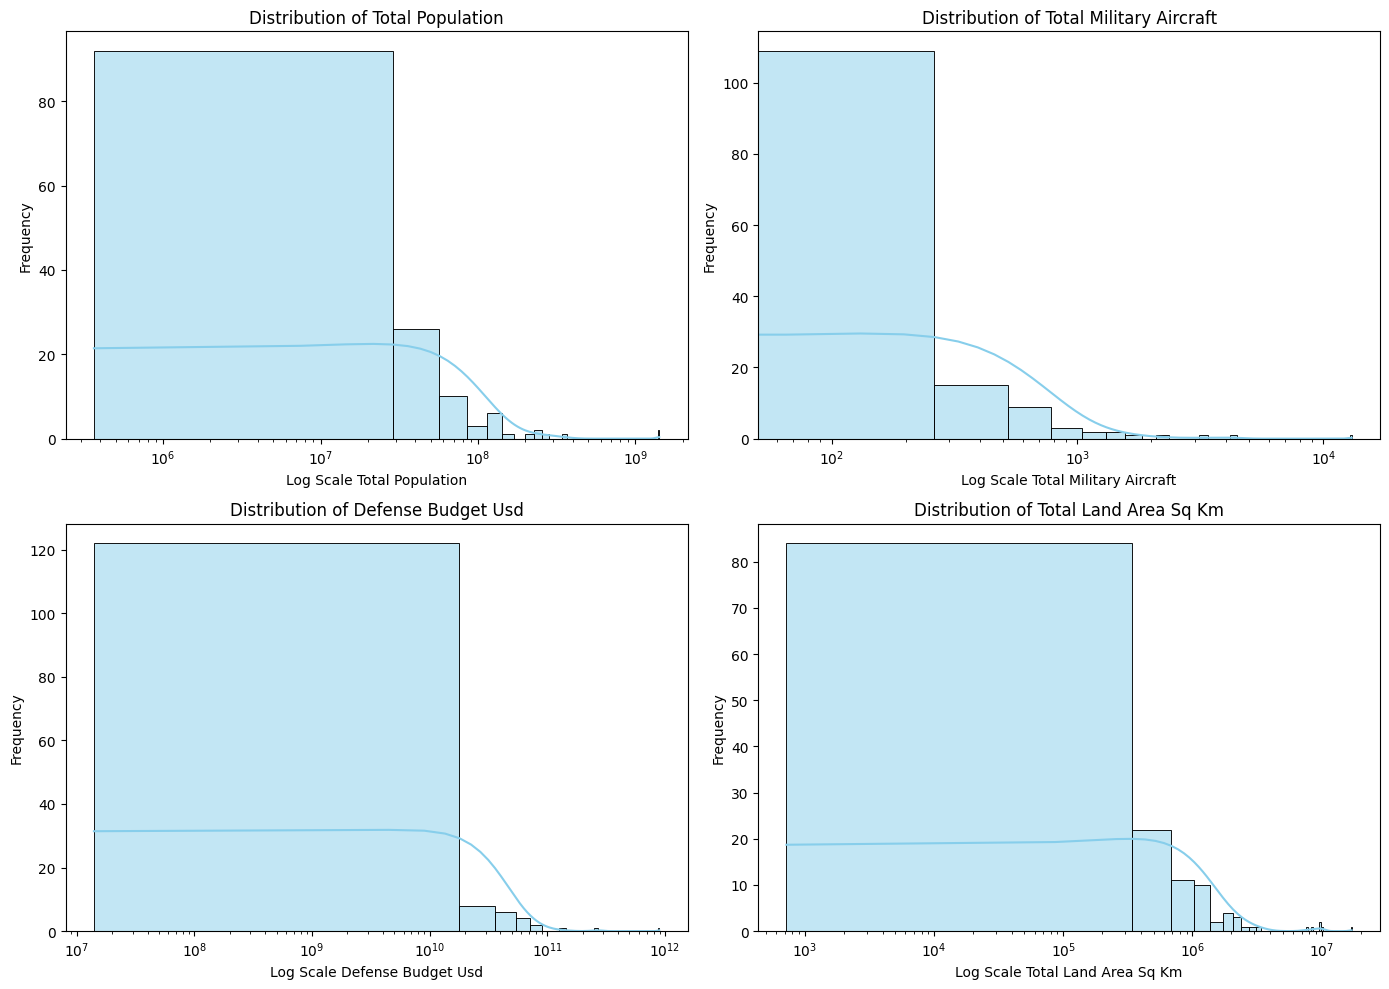

Histograms for selected key numerical columns displayed.


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a subset of key numerical columns for visualization
selected_columns = [
    'total_population',
    'total_military_aircraft',
    'defense_budget_usd',
    'total_land_area_sq_km'
]

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Create a histogram for each selected column
for i, col in enumerate(selected_columns):
    sns.histplot(df_revisit[col], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')
    # Add a log scale for highly skewed data if needed, or adjust xlim
    if df_revisit[col].max() > 10 * df_revisit[col].median(): # Simple heuristic for high skewness
        axes[i].set_xscale('log')
        axes[i].set_xlabel(f'Log Scale {col.replace("_", " ").title()}')

plt.tight_layout()
plt.show()
print("Histograms for selected key numerical columns displayed.")

In [51]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### Summary of Visualizations

The visualizations of key numerical columns confirmed the highly skewed distributions identified in the descriptive statistics:

*   **Total Population:** The histogram for `total_population` clearly shows a long tail towards higher values, indicating that most countries have smaller populations, while a few have extremely large populations. The application of a log scale effectively spreads out the data, making the distribution more interpretable and highlighting the wide range.

*   **Total Military Aircraft:** Similar to population, `total_military_aircraft` also exhibits a heavily right-skewed distribution. A large number of countries have very few aircraft, with a sharp drop-off as the number of aircraft increases, indicating that only a handful of nations possess very large air forces. The log-scaled plot better illustrates the spread among countries with more aircraft.

*   **Defense Budget USD:** The `defense_budget_usd` distribution is extremely skewed, with most countries having relatively low defense budgets and a few having significantly higher budgets, resulting in a pronounced long tail. The log scale was crucial here to visualize the distribution across the entire range of budgets, from small to extremely large.

*   **Total Land Area Sq Km:** This column also shows a right-skewed distribution, reflecting that most countries have smaller land areas, while a few are geographically very large. The log scale helps in understanding the distribution of land areas more evenly.

**Overall Observations from Visualizations:**

1.  **Extreme Skewness:** All visualized columns demonstrate extreme right-skewness, where a large proportion of data points are concentrated at the lower end, and a few data points extend to very high values.
2.  **Presence of Outliers:** The long tails in the distributions indicate the presence of significant outliers, corresponding to countries with exceptionally high values for these metrics (e.g., highly populated countries, major military powers, or geographically large nations).
3.  **Effectiveness of Log Transformation:** The use of a log scale was essential for these highly skewed distributions to make them more comprehensible and to reveal patterns that would otherwise be obscured by the concentration of data at the lower end.

These visualizations reinforce the need for careful consideration of data distribution when performing further analysis, modeling, or feature engineering, especially regarding potential transformations or robust statistical methods.

## Final Task

### Subtask:
Summarize the findings from the data quality review and provide actionable recommendations for further cleaning or specific analysis based on the observed issues.


## Summary:

### Q&A
The data quality review identified several issues and provided recommendations. The key findings include:
*   The `total_naval_fleet_tonnage_mt` column has 98 missing entries, and imputing these with `0` would be misleading, as it would imply absence rather than unknown data.
*   Most numerical columns exhibit significant right-skewness and wide ranges, indicating the presence of outliers, such as `total_population` ranging from 364,036 to 1.4 billion, with a mean of 54.5 million and a median of 14.6 million.
*   Data types are generally correct, with `float64` appropriately used for columns that may contain `NaN` values.

### Data Analysis Key Findings
*   The `total_naval_fleet_tonnage_mt` column is the only one with missing values after initial numeric coercion, containing 98 `NaN` entries.
*   Imputing `0` for `total_naval_fleet_tonnage_mt` is deemed inappropriate because `0` represents a true absence, while `NaN` signifies missing or unreported data.
*   All columns were correctly identified with appropriate data types: `country` as `object` and all other numerical columns as `int64` or `float64` (the latter correctly used for columns with `NaN` values). No unexpected coercion errors were found.
*   Descriptive statistics reveal that many numerical columns, including `total_population`, `total_military_aircraft`, and `defense_budget_usd`, are highly skewed with wide ranges. For instance, `total_population` has a minimum of 364,036, a maximum of 1.4 billion, a mean of 54.5 million, and a median of 14.6 million.
*   The presence of a `0` minimum value in many military asset columns (e.g., `fighter_aircraft`, `tanks`) typically indicates the true absence of that asset for certain countries.
*   Visualizations (histograms) confirmed the extreme right-skewness and long tails for key columns such as `total_population`, `total_military_aircraft`, `defense_budget_usd`, and `total_land_area_sq_km`. Logarithmic scales were necessary to properly interpret these distributions.

### Insights or Next Steps
*   For `total_naval_fleet_tonnage_mt`, preserve `NaN` values to accurately represent missing data, or use median imputation if imputation is essential, due to its robustness to skewness.
*   When performing further analysis or modeling on highly skewed numerical columns, consider applying data transformations (e.g., logarithmic transformation) or using robust statistical methods to account for the wide ranges and presence of outliers.
